In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm

from statsmodels.tsa.stattools import (
    coint,
    adfuller
)

import warnings

warnings.filterwarnings("ignore")

data = pd.read_csv(
    "nifty_50_comp_price_data.csv",
    index_col=0,
    parse_dates=True
)

data.head()


,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJFINANCE.NS,BEL.NS,BHARTIARTL.NS,CIPLA.NS,...,SHRIRAMFIN.NS,SUNPHARMA.NS,TATACONSUM.NS,TATASTEEL.NS,TCS.NS,TECHM.NS,TITAN.NS,TRENT.NS,ULTRACEMCO.NS,WIPRO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-01,205.794525,361.062561,1403.106934,1690.746338,745.586914,2599.727783,413.532196,29.713722,433.316498,449.420258,...,201.816833,406.074036,306.714355,38.457085,1841.149292,602.617493,1132.704956,526.402710,3942.765625,113.709183
2020-01-02,209.111359,366.321014,1470.294067,1688.342407,753.802612,2575.711670,414.973724,30.603800,435.132721,447.153778,...,204.996552,406.681732,306.240814,39.862995,1832.697754,605.740845,1133.538574,538.030945,4117.158691,113.984634
2020-01-03,206.240067,365.699554,1461.883301,1651.334717,739.860840,2535.314453,409.833008,29.951080,435.037109,443.801361,...,204.899414,415.704620,301.363312,39.768440,1869.222168,612.897095,1117.942017,532.614319,4092.329102,115.269989
2020-01-06,197.576599,363.500580,1438.667969,1609.613159,720.242676,2506.924316,390.604340,28.764307,429.827362,440.779388,...,197.338669,411.356781,295.586090,38.909275,1869.051880,609.180664,1136.481201,526.700928,4032.095703,115.751999
2020-01-07,202.032074,367.898529,1454.603760,1625.877197,722.732300,2507.171875,391.674469,28.586292,425.477966,442.526489,...,198.601746,417.387543,298.237915,39.143593,1873.639404,614.478577,1137.805542,529.682434,4114.540039,117.152138


In [2]:
train = data.loc[
    :"2023-12-31"
]

test = data.loc[
    "2024-01-01":
]

print(
    "Train:",
    train.index.min(),
    train.index.max()
)

print(
    "Test:",
    test.index.min(),
    test.index.max()
)

Train: 2020-01-01 00:00:00 2023-12-29 00:00:00
Test: 2024-01-01 00:00:00 2026-06-25 00:00:00


In [3]:
returns = train.pct_change()

corr_matrix = returns.corr()

candidate_pairs = []

for i in range(len(corr_matrix.columns)):

    for j in range(i + 1,
                   len(corr_matrix.columns)):

        stock1 = corr_matrix.columns[i]
        stock2 = corr_matrix.columns[j]

        corr = corr_matrix.iloc[i, j]

        if corr > 0.40:

            candidate_pairs.append(
                [
                    stock1,
                    stock2,
                    corr
                ]
            )

candidate_pairs = pd.DataFrame(
    candidate_pairs,
    columns=[
        "Stock1",
        "Stock2",
        "Correlation"
    ]
)

print(
    "Candidate Pairs:",
    len(candidate_pairs)
)

Candidate Pairs: 254


In [4]:
results = []

for _, row in candidate_pairs.iterrows():

    stock1 = row["Stock1"]
    stock2 = row["Stock2"]

    try:

        score, coint_pvalue, _ = coint(
            train[stock1],
            train[stock2]
        )

        beta = np.polyfit(
            train[stock2],
            train[stock1],
            1
        )[0]

        spread = (
            train[stock1]
            - beta * train[stock2]
        )

        adf_pvalue = adfuller(
            spread.dropna()
        )[1]

        results.append(
            [
                stock1,
                stock2,
                row["Correlation"],
                coint_pvalue,
                adf_pvalue
            ]
        )

    except:

        continue

In [5]:
pairs_df = pd.DataFrame(
    results,
    columns=[
        "Stock1",
        "Stock2",
        "Correlation",
        "Cointegration_P",
        "ADF_P"
    ]
)

pairs_df = pairs_df.sort_values(
    [
        "Cointegration_P",
        "ADF_P"
    ]
)

strong_pairs = pairs_df[
    (pairs_df["Cointegration_P"] < 0.05)
    &
    (pairs_df["ADF_P"] < 0.05)
]

print(
    "Strong Pairs:",
    len(strong_pairs)
)

strong_pairs.head(20)

Strong Pairs: 27


,Stock1,Stock2,Correlation,Cointegration_P,ADF_P
20,AXISBANK.NS,INDUSINDBK.NS,0.586723,0.000038,0.000004
177,INDUSINDBK.NS,SHRIRAMFIN.NS,0.476235,0.000858,0.000132
174,INDUSINDBK.NS,LT.NS,0.485595,0.001909,0.000303
157,ICICIBANK.NS,INDUSINDBK.NS,0.559069,0.002216,0.000311
213,M&M.NS,MARUTI.NS,0.524620,0.002486,0.000434
90,GRASIM.NS,INDUSINDBK.NS,0.421522,0.003025,0.000532
236,SBILIFE.NS,TITAN.NS,0.413837,0.005582,0.001070
1,ADANIPORTS.NS,GRASIM.NS,0.439538,0.015838,0.003502
156,HINDUNILVR.NS,TATACONSUM.NS,0.426794,0.015941,0.003523
114,HDFCBANK.NS,INDUSINDBK.NS,0.475577,0.016031,0.003476


In [6]:
selected_pairs = strong_pairs.head(10)

selected_pairs

,Stock1,Stock2,Correlation,Cointegration_P,ADF_P
20,AXISBANK.NS,INDUSINDBK.NS,0.586723,0.000038,0.000004
177,INDUSINDBK.NS,SHRIRAMFIN.NS,0.476235,0.000858,0.000132
174,INDUSINDBK.NS,LT.NS,0.485595,0.001909,0.000303
157,ICICIBANK.NS,INDUSINDBK.NS,0.559069,0.002216,0.000311
213,M&M.NS,MARUTI.NS,0.524620,0.002486,0.000434
90,GRASIM.NS,INDUSINDBK.NS,0.421522,0.003025,0.000532
236,SBILIFE.NS,TITAN.NS,0.413837,0.005582,0.001070
1,ADANIPORTS.NS,GRASIM.NS,0.439538,0.015838,0.003502
156,HINDUNILVR.NS,TATACONSUM.NS,0.426794,0.015941,0.003523
114,HDFCBANK.NS,INDUSINDBK.NS,0.475577,0.016031,0.003476


In [8]:
def backtest_pair(
    stock1,
    stock2,
    data,
    entry_z=2,
    exit_z=0
):

    x = sm.add_constant(
        data[stock2]
    )

    model = sm.OLS(
        data[stock1],
        x
    ).fit()

    beta = model.params[stock2]

    spread = (
        data[stock1]
        - beta * data[stock2]
    )

    zscore = (
        spread - spread.mean()
    ) / spread.std()

    position = pd.Series(
        0,
        index=zscore.index
    )

    current_position = 0

    for i in range(len(zscore)):

        z = zscore.iloc[i]

        if current_position == 0:

            if z > entry_z:
                current_position = -1

            elif z < -entry_z:
                current_position = 1

        elif current_position == 1:

            if z >= exit_z:
                current_position = 0

        elif current_position == -1:

            if z <= -exit_z:
                current_position = 0

        position.iloc[i] = current_position

    stock1_ret = data[
        stock1
    ].pct_change()

    stock2_ret = data[
        stock2
    ].pct_change()

    spread_ret = (
        stock1_ret
        - beta * stock2_ret
    )

    strategy_ret = (
        position.shift(1)
        * spread_ret
    )

    return strategy_ret.fillna(0)

In [9]:
pair_returns = pd.DataFrame()

for _, row in selected_pairs.iterrows():

    stock1 = row["Stock1"]
    stock2 = row["Stock2"]

    pair_name = (
        f"{stock1}_{stock2}"
    )

    pair_returns[pair_name] = backtest_pair(
        stock1,
        stock2,
        test
    )

In [10]:
active_pairs = (
    pair_returns != 0
).sum(axis=1)

portfolio_ret = (
    pair_returns.sum(axis=1)
    /
    active_pairs.replace(
        0,
        np.nan
    )
)

portfolio_ret = portfolio_ret.fillna(0)

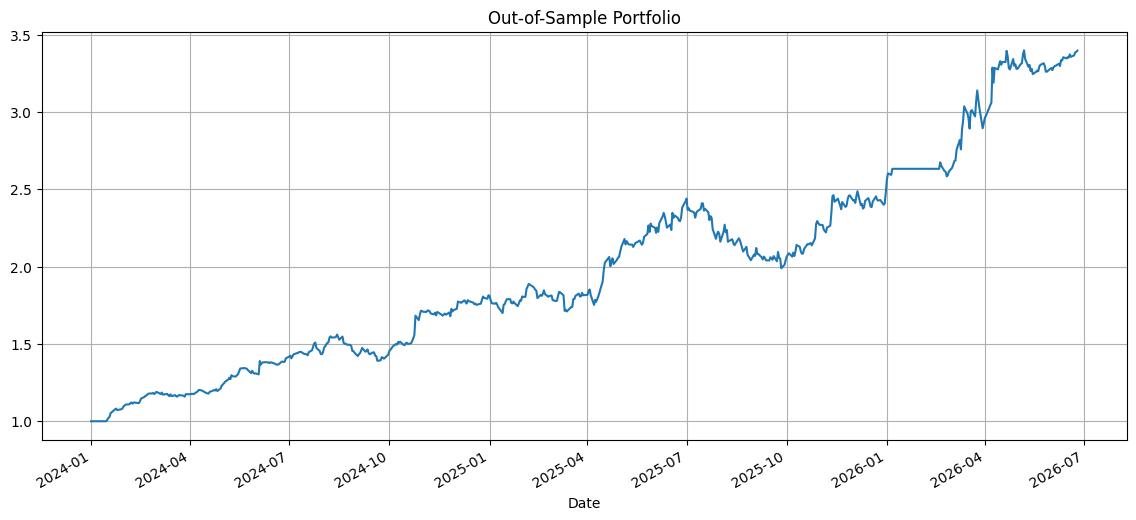

In [11]:
equity_curve = (
    1 + portfolio_ret
).cumprod()

plt.figure(figsize=(14,6))

equity_curve.plot()

plt.title(
    "Out-of-Sample Portfolio"
)

plt.grid(True)

plt.show()

In [12]:
total_return = (
    equity_curve.iloc[-1] - 1
)

years = (
    len(portfolio_ret)
    / 252
)

cagr = (
    equity_curve.iloc[-1]
) ** (1 / years) - 1

sharpe = (
    portfolio_ret.mean()
    /
    portfolio_ret.std()
) * np.sqrt(252)

rolling_max = (
    equity_curve.cummax()
)

drawdown = (
    equity_curve
    / rolling_max
    - 1
)

max_dd = drawdown.min()

print(
    f"Total Return: {total_return:.2%}"
)

print(
    f"CAGR: {cagr:.2%}"
)

print(
    f"Sharpe: {sharpe:.2f}"
)

print(
    f"Max Drawdown: {max_dd:.2%}"
)

Total Return: 239.83%
CAGR: 65.08%
Sharpe: 2.39
Max Drawdown: -18.47%


In [13]:
selected_pairs.to_csv(
    "selected_pairs_train.csv",
    index=False
)